In [ ]:
# ============================================
# CELL 1: Install / import required libraries
# ============================================

# In Colab, most of these are usually preinstalled.
# Run this only if any import fails.
# !pip install pandas numpy matplotlib seaborn scikit-learn plotly openpyxl

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, IsolationForest

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay
)

In [ ]:
# ============================================
# CELL 2: Upload / load the CSV file
# ============================================

# Option A: If file is already uploaded in Colab session

from google.colab import drive
drive.mount('/content/drive')
file_path = "/content/drive/My Drive/Colab Notebooks/loan_portfolio.csv"

# Option B: Uncomment to upload manually from local machine
# from google.colab import files
# uploaded = files.upload()
# file_path = list(uploaded.keys())[0]

df = pd.read_csv(file_path)
print("Data loaded successfully.")
print("Shape:", df.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data loaded successfully.
Shape: (100, 10)


In [ ]:
# ============================================
# CELL 3: Quick look at the data
# ============================================

display(df.head(10))
display(df.tail(5))

,Loan_ID,Customer_Type,Annual_Income,Debt_to_Income,Credit_History_Length,Loan_Amount,Interest_Rate,Loan_Term_Months,Past_Default,PD
0,1,Corporate,2676791,0.47,15,399593,13.39,36,0,0.22
1,2,Retail,2740108,0.15,23,825131,12.80,36,0,0.02
2,3,Corporate,4863177,0.20,15,83686,6.09,48,0,0.18
3,4,Corporate,3383597,0.19,5,77661,5.05,48,0,0.07
4,5,Retail,95953,0.62,21,578535,11.02,24,0,0.12
5,6,Corporate,4019618,0.70,14,255121,14.15,36,0,0.09
6,7,Corporate,2627480,0.57,2,682108,9.68,36,0,0.11
7,8,Corporate,4227571,0.87,11,377257,9.86,60,0,0.22
8,9,Retail,2952097,0.40,19,276765,6.36,48,0,0.09
9,10,Retail,187164,0.33,7,156106,12.23,36,1,0.17


,Loan_ID,Customer_Type,Annual_Income,Debt_to_Income,Credit_History_Length,Loan_Amount,Interest_Rate,Loan_Term_Months,Past_Default,PD
95,96,Retail,478345,0.54,15,965614,12.57,60,0,0.30
96,97,Corporate,779074,0.55,15,550677,4.80,12,0,0.11
97,98,Corporate,3715501,0.80,24,656465,5.75,60,0,0.23
98,99,Corporate,1909490,0.42,22,313571,11.67,60,0,0.12
99,100,Retail,3917857,0.21,14,694106,11.64,36,0,0.14


In [ ]:
# ============================================
# CELL 4: Column names and data types
# ============================================

print("Columns:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)

Columns:
['Loan_ID', 'Customer_Type', 'Annual_Income', 'Debt_to_Income', 'Credit_History_Length', 'Loan_Amount', 'Interest_Rate', 'Loan_Term_Months', 'Past_Default', 'PD']

Data types:
Loan_ID                    int64
Customer_Type             object
Annual_Income              int64
Debt_to_Income           float64
Credit_History_Length      int64
Loan_Amount                int64
Interest_Rate            float64
Loan_Term_Months           int64
Past_Default               int64
PD                       float64
dtype: object


In [ ]:
# ============================================
# CELL 5: Basic dataset information
# ============================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Loan_ID                100 non-null    int64  
 1   Customer_Type          100 non-null    object 
 2   Annual_Income          100 non-null    int64  
 3   Debt_to_Income         100 non-null    float64
 4   Credit_History_Length  100 non-null    int64  
 5   Loan_Amount            100 non-null    int64  
 6   Interest_Rate          100 non-null    float64
 7   Loan_Term_Months       100 non-null    int64  
 8   Past_Default           100 non-null    int64  
 9   PD                     100 non-null    float64
dtypes: float64(3), int64(6), object(1)
memory usage: 7.9+ KB


In [ ]:
# ============================================
# CELL 6: Missing values check
# ============================================

missing = df.isnull().sum().sort_values(ascending=False)
missing_df = pd.DataFrame({
    "column": missing.index,
    "missing_count": missing.values,
    "missing_percent": (missing.values / len(df)) * 100
})
display(missing_df)

,column,missing_count,missing_percent
0,Loan_ID,0,0.0
1,Customer_Type,0,0.0
2,Annual_Income,0,0.0
3,Debt_to_Income,0,0.0
4,Credit_History_Length,0,0.0
5,Loan_Amount,0,0.0
6,Interest_Rate,0,0.0
7,Loan_Term_Months,0,0.0
8,Past_Default,0,0.0
9,PD,0,0.0


In [ ]:
# ============================================
# CELL 7: Duplicate rows check
# ============================================

print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Loan_ID values:", df["Loan_ID"].duplicated().sum())

Duplicate rows: 0
Duplicate Loan_ID values: 0


In [ ]:
# ============================================
# CELL 8: Descriptive statistics
# ============================================

display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Loan_ID,100.0,NaN,NaN,NaN,50.5,29.011492,1.0,25.75,50.5,75.25,100.0
Customer_Type,100,2,Retail,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Annual_Income,100.0,NaN,NaN,NaN,2671591.57,1444021.046192,56790.0,1366360.75,2778969.0,3980000.75,4969003.0
Debt_to_Income,100.0,NaN,NaN,NaN,0.5538,0.243442,0.11,0.3725,0.57,0.78,0.9
Credit_History_Length,100.0,NaN,NaN,NaN,13.01,7.115916,1.0,6.0,14.5,19.0,24.0
Loan_Amount,100.0,NaN,NaN,NaN,509767.28,273871.761972,11062.0,274199.5,544523.5,720938.75,965614.0
Interest_Rate,100.0,NaN,NaN,NaN,9.0689,3.355599,3.4,6.04,9.185,12.17,14.88
Loan_Term_Months,100.0,NaN,NaN,NaN,34.92,17.149185,12.0,24.0,36.0,48.0,60.0
Past_Default,100.0,NaN,NaN,NaN,0.13,0.337998,0.0,0.0,0.0,0.0,1.0
PD,100.0,NaN,NaN,NaN,0.1572,0.08907,0.01,0.08,0.165,0.2325,0.3


In [ ]:
# ============================================
# CELL 9: Category frequency tables
# ============================================

print("Customer Type counts:")
display(df["Customer_Type"].value_counts())

print("\nPast Default counts:")
display(df["Past_Default"].value_counts())

Customer Type counts:


,count
Customer_Type,
Retail,53
Corporate,47



Past Default counts:


,count
Past_Default,
0,87
1,13


In [ ]:
# ============================================
# CELL 10: Sanity checks for important ranges
# ============================================

print("PD min/max:", df["PD"].min(), df["PD"].max())
print("DTI min/max:", df["Debt_to_Income"].min(), df["Debt_to_Income"].max())
print("Interest rate min/max:", df["Interest_Rate"].min(), df["Interest_Rate"].max())
print("Loan term unique values:", sorted(df["Loan_Term_Months"].unique()))

PD min/max: 0.01 0.3
DTI min/max: 0.11 0.9
Interest rate min/max: 3.4 14.88
Loan term unique values: [np.int64(12), np.int64(24), np.int64(36), np.int64(48), np.int64(60)]


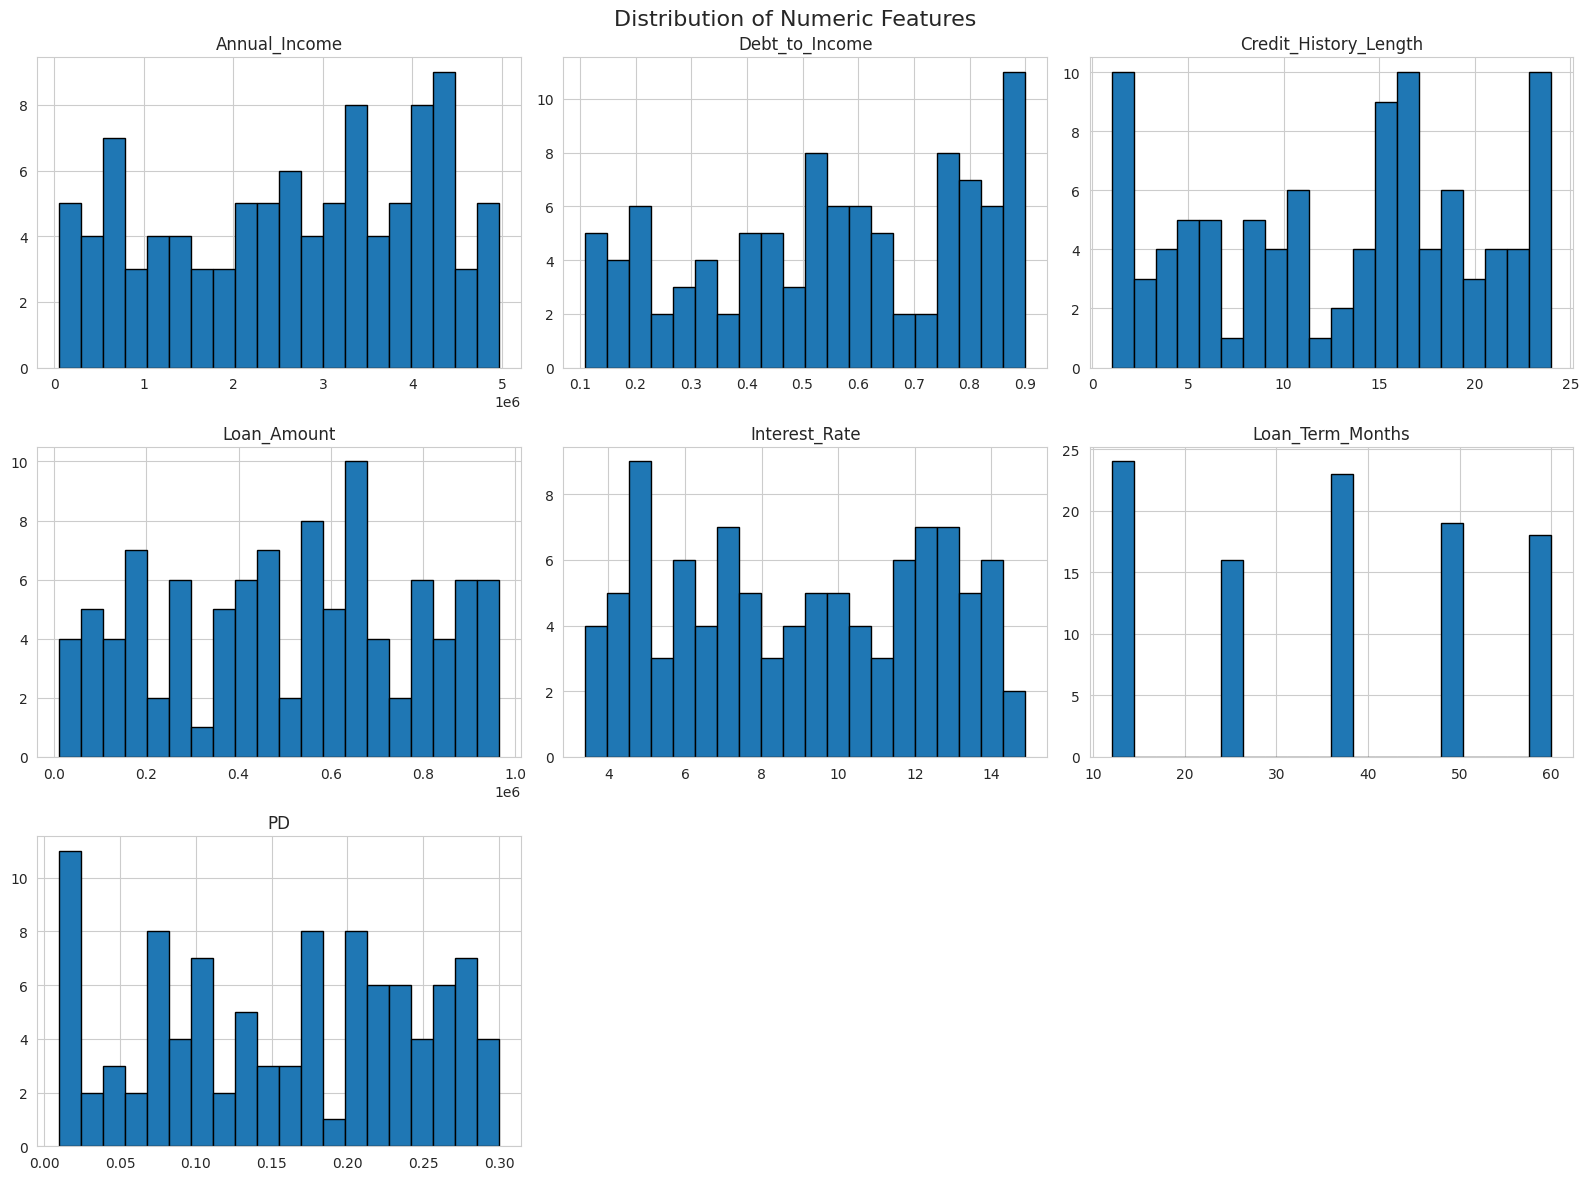

In [ ]:
# ============================================
# CELL 11: Histograms for numeric columns
# ============================================

numeric_cols = [
    "Annual_Income", "Debt_to_Income", "Credit_History_Length",
    "Loan_Amount", "Interest_Rate", "Loan_Term_Months", "PD"
]

df[numeric_cols].hist(figsize=(16, 12), bins=20, edgecolor="black")
plt.suptitle("Distribution of Numeric Features", fontsize=16)
plt.tight_layout()
plt.show()

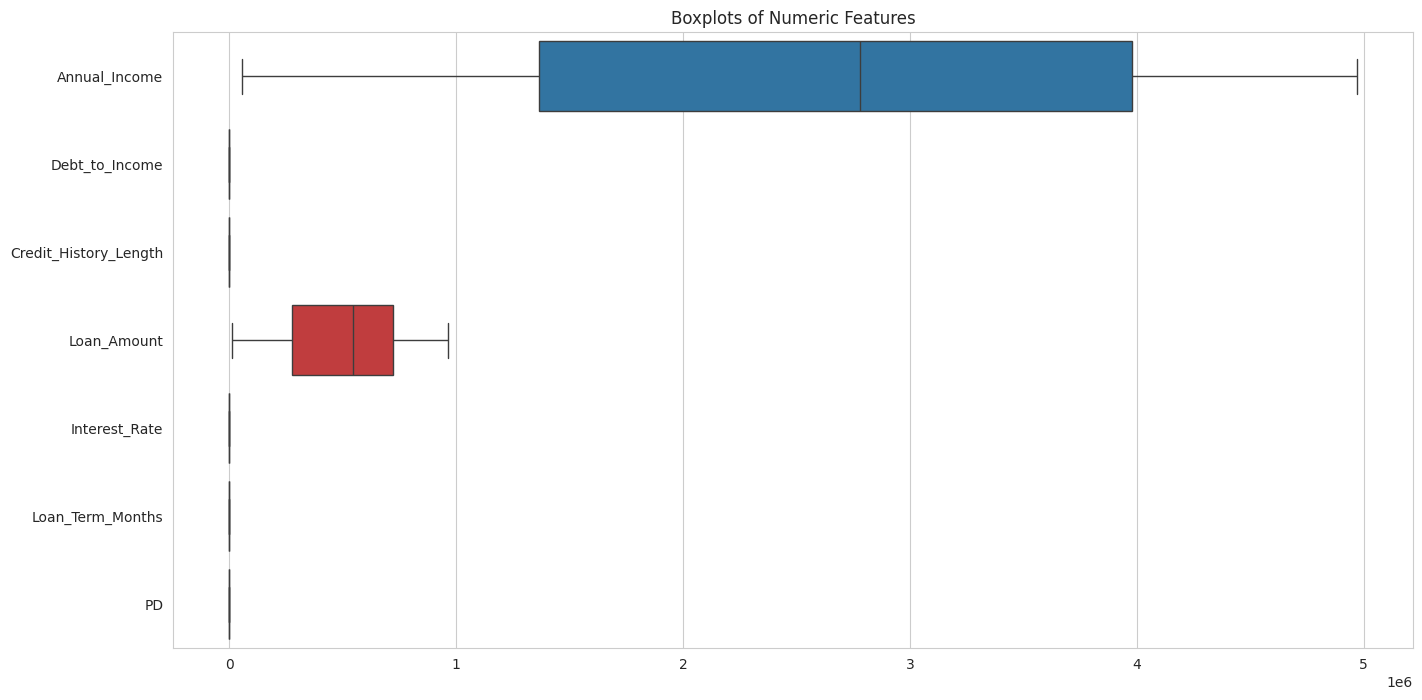

In [ ]:
# ============================================
# CELL 12: Boxplots for numeric columns
# ============================================

plt.figure(figsize=(16, 8))
sns.boxplot(data=df[numeric_cols], orient="h")
plt.title("Boxplots of Numeric Features")
plt.show()

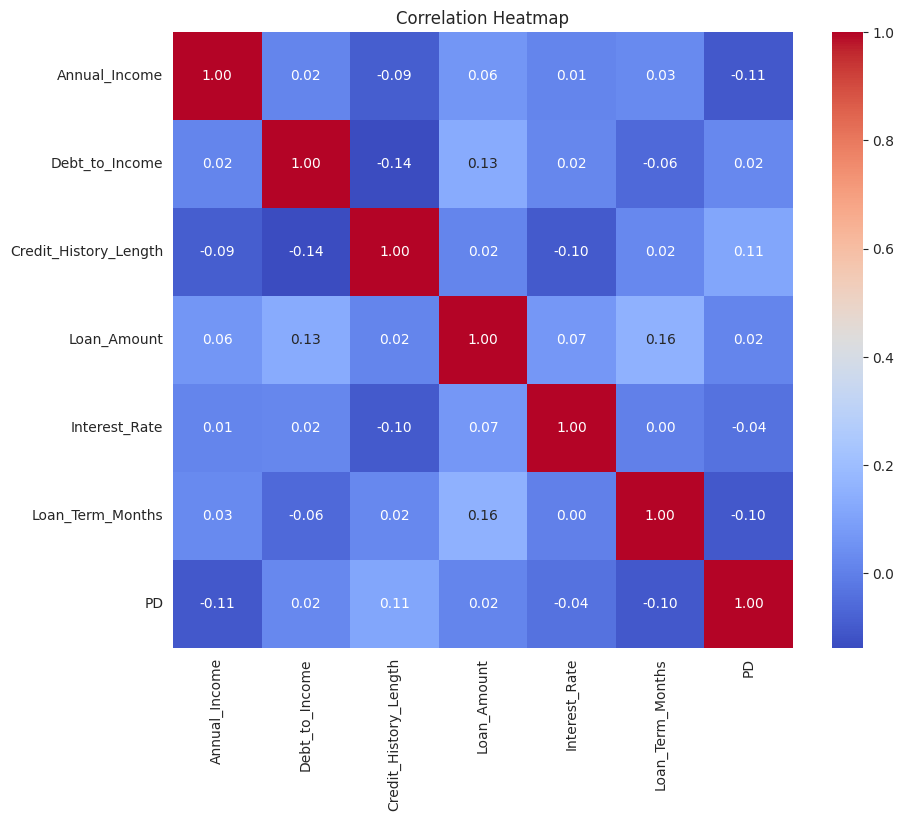

In [ ]:
# ============================================
# CELL 13: Correlation heatmap
# ============================================

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

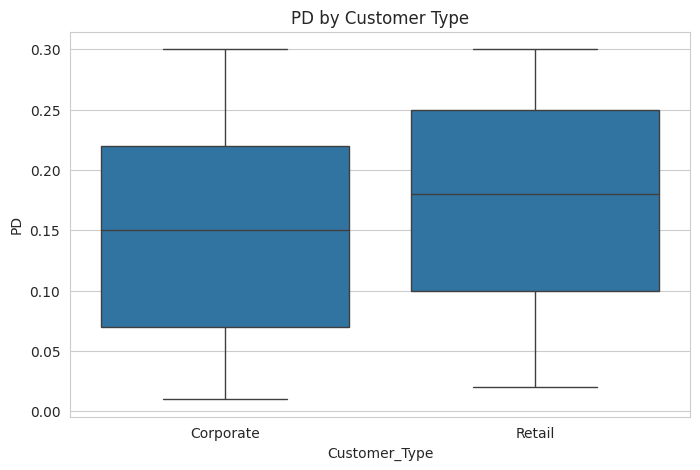

,count,mean,median,min,max
Customer_Type,,,,,
Corporate,47,0.141489,0.15,0.01,0.3
Retail,53,0.171132,0.18,0.02,0.3


In [ ]:
# ============================================
# CELL 14: PD by Customer Type
# ============================================

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Customer_Type", y="PD")
plt.title("PD by Customer Type")
plt.show()

display(df.groupby("Customer_Type")["PD"].agg(["count", "mean", "median", "min", "max"]))

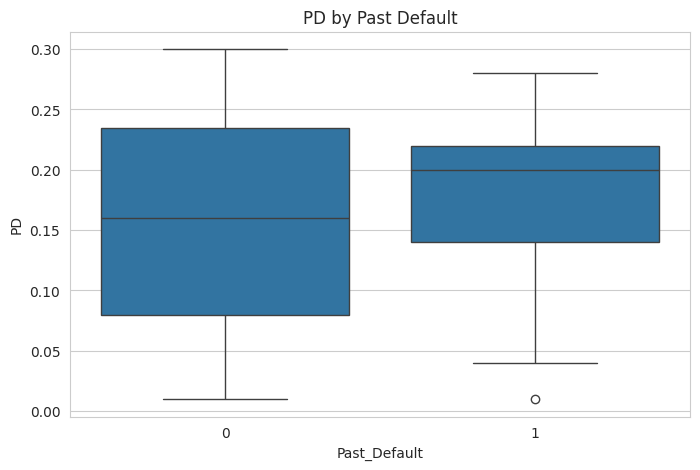

,count,mean,median,min,max
Past_Default,,,,,
0,87,0.155172,0.16,0.01,0.30
1,13,0.170769,0.20,0.01,0.28


In [ ]:
# ============================================
# CELL 15: PD by Past Default
# ============================================

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Past_Default", y="PD")
plt.title("PD by Past Default")
plt.show()

display(df.groupby("Past_Default")["PD"].agg(["count", "mean", "median", "min", "max"]))

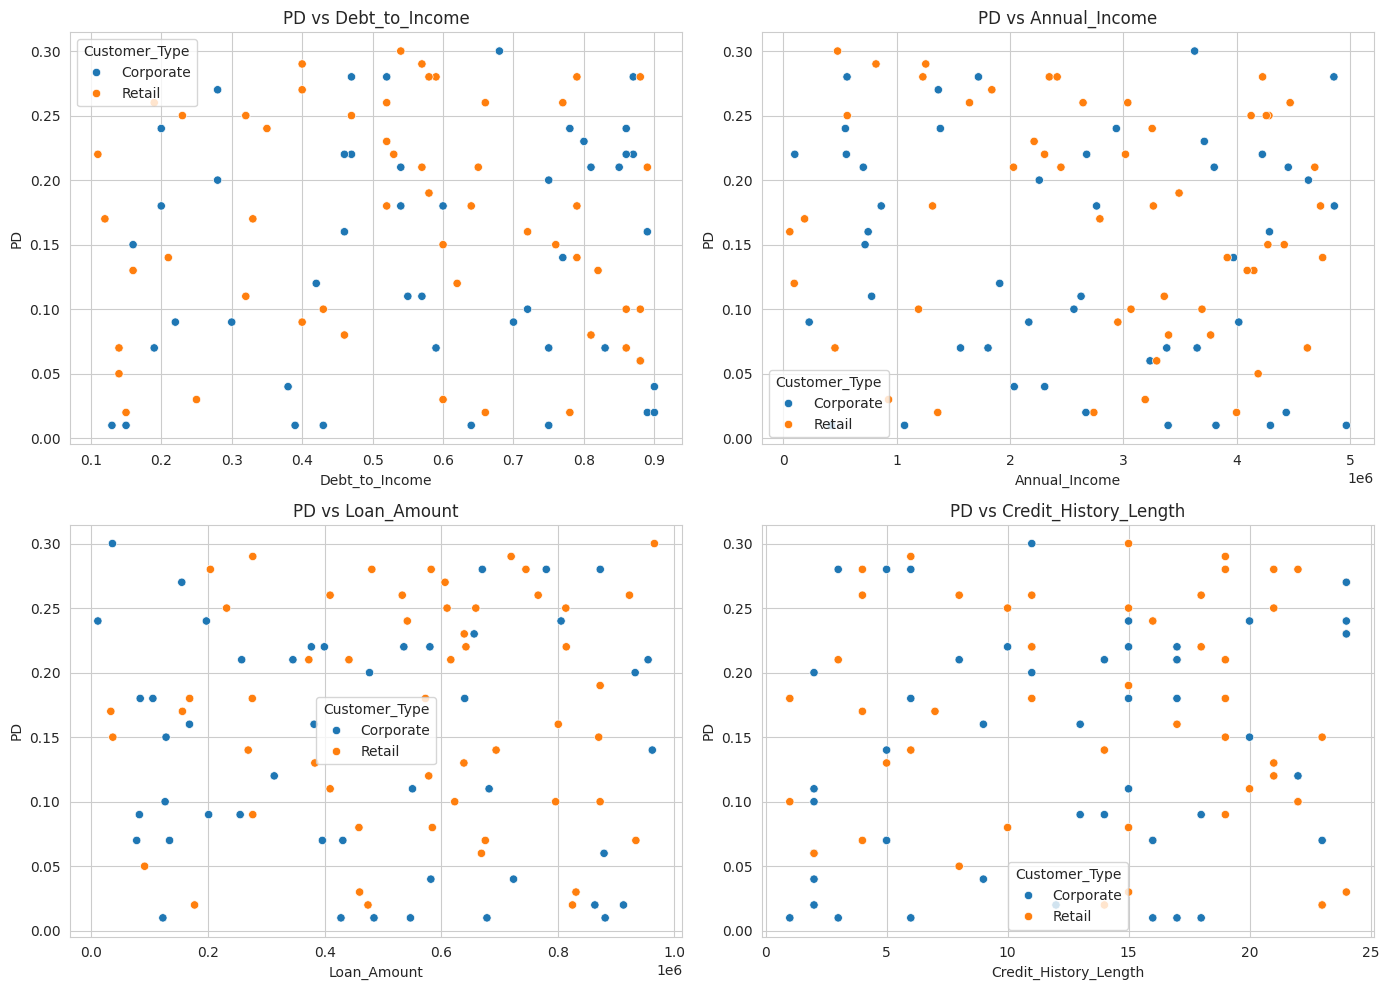

In [ ]:
# ============================================
# CELL 16: Scatterplots of key risk relationships
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.scatterplot(data=df, x="Debt_to_Income", y="PD", hue="Customer_Type", ax=axes[0, 0])
axes[0, 0].set_title("PD vs Debt_to_Income")

sns.scatterplot(data=df, x="Annual_Income", y="PD", hue="Customer_Type", ax=axes[0, 1])
axes[0, 1].set_title("PD vs Annual_Income")

sns.scatterplot(data=df, x="Loan_Amount", y="PD", hue="Customer_Type", ax=axes[1, 0])
axes[1, 0].set_title("PD vs Loan_Amount")

sns.scatterplot(data=df, x="Credit_History_Length", y="PD", hue="Customer_Type", ax=axes[1, 1])
axes[1, 1].set_title("PD vs Credit_History_Length")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# CELL 17: Create derived features
# ============================================

df["Income_to_Loan_Ratio"] = df["Annual_Income"] / df["Loan_Amount"]
df["Loan_to_Income_Ratio"] = df["Loan_Amount"] / df["Annual_Income"]
df["High_DTI_Flag"] = (df["Debt_to_Income"] > 0.60).astype(int)
df["Short_Credit_History_Flag"] = (df["Credit_History_Length"] < 5).astype(int)

display(df.head())

,Loan_ID,Customer_Type,Annual_Income,Debt_to_Income,Credit_History_Length,Loan_Amount,Interest_Rate,Loan_Term_Months,Past_Default,PD,Income_to_Loan_Ratio,Loan_to_Income_Ratio,High_DTI_Flag,Short_Credit_History_Flag
0,1,Corporate,2676791,0.47,15,399593,13.39,36,0,0.22,6.698794,0.149281,0,0
1,2,Retail,2740108,0.15,23,825131,12.80,36,0,0.02,3.320816,0.301131,0,0
2,3,Corporate,4863177,0.20,15,83686,6.09,48,0,0.18,58.112193,0.017208,0,0
3,4,Corporate,3383597,0.19,5,77661,5.05,48,0,0.07,43.568805,0.022952,0,0
4,5,Retail,95953,0.62,21,578535,11.02,24,0,0.12,0.165855,6.029358,1,0


In [ ]:
# ============================================
# CELL 18: Create risk buckets from PD
# Tune the thresholds here for learning
# ============================================

low_threshold = 0.10
high_threshold = 0.20

def assign_risk_bucket(pd_value):
    if pd_value < low_threshold:
        return "Low"
    elif pd_value < high_threshold:
        return "Medium"
    else:
        return "High"

df["Risk_Bucket"] = df["PD"].apply(assign_risk_bucket)

display(df[["Loan_ID", "PD", "Risk_Bucket"]].head(10))
print(df["Risk_Bucket"].value_counts())

,Loan_ID,PD,Risk_Bucket
0,1,0.22,High
1,2,0.02,Low
2,3,0.18,Medium
3,4,0.07,Low
4,5,0.12,Medium
5,6,0.09,Low
6,7,0.11,Medium
7,8,0.22,High
8,9,0.09,Low
9,10,0.17,Medium


Risk_Bucket
High      41
Low       30
Medium    29
Name: count, dtype: int64


In [ ]:
# ============================================
# CELL 19: Portfolio-level metrics
# ============================================

portfolio_summary = {
    "Total_Loans": len(df),
    "Total_Loan_Amount": df["Loan_Amount"].sum(),
    "Average_Loan_Amount": df["Loan_Amount"].mean(),
    "Average_Income": df["Annual_Income"].mean(),
    "Average_DTI": df["Debt_to_Income"].mean(),
    "Average_PD": df["PD"].mean(),
    "Past_Default_Rate": df["Past_Default"].mean()
}

portfolio_summary_df = pd.DataFrame(portfolio_summary, index=["Portfolio"])
display(portfolio_summary_df.T)

,Portfolio
Total_Loans,1.000000e+02
Total_Loan_Amount,5.097673e+07
Average_Loan_Amount,5.097673e+05
Average_Income,2.671592e+06
Average_DTI,5.538000e-01
Average_PD,1.572000e-01
Past_Default_Rate,1.300000e-01


In [ ]:
# ============================================
# CELL 20: Segment-wise portfolio metrics
# ============================================

segment_summary = df.groupby("Customer_Type").agg(
    Loan_Count=("Loan_ID", "count"),
    Total_Loan_Amount=("Loan_Amount", "sum"),
    Avg_Loan_Amount=("Loan_Amount", "mean"),
    Avg_Income=("Annual_Income", "mean"),
    Avg_DTI=("Debt_to_Income", "mean"),
    Avg_PD=("PD", "mean"),
    Past_Default_Rate=("Past_Default", "mean")
).reset_index()

display(segment_summary)

,Customer_Type,Loan_Count,Total_Loan_Amount,Avg_Loan_Amount,Avg_Income,Avg_DTI,Avg_PD,Past_Default_Rate
0,Corporate,47,21869464,465307.744681,2.547538e+06,0.579787,0.141489,0.148936
1,Retail,53,29107264,549193.660377,2.781601e+06,0.530755,0.171132,0.113208


In [ ]:
# ============================================
# CELL 21: Risk bucket metrics
# ============================================

risk_bucket_summary = df.groupby("Risk_Bucket").agg(
    Loan_Count=("Loan_ID", "count"),
    Total_Loan_Amount=("Loan_Amount", "sum"),
    Avg_PD=("PD", "mean"),
    Avg_DTI=("Debt_to_Income", "mean"),
    Avg_Income=("Annual_Income", "mean")
).reset_index()

display(risk_bucket_summary)

,Risk_Bucket,Loan_Count,Total_Loan_Amount,Avg_PD,Avg_DTI,Avg_Income
0,High,41,22643480,0.246829,0.565854,2.530937e+06
1,Low,30,15138878,0.047000,0.538333,2.813228e+06
2,Medium,29,13194370,0.144483,0.552759,2.723928e+06


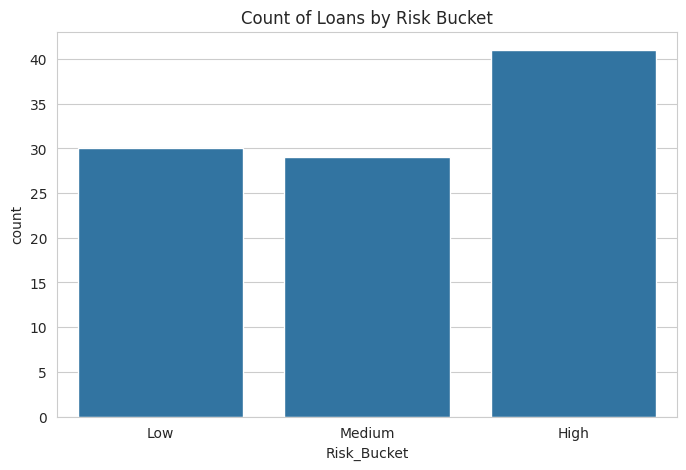

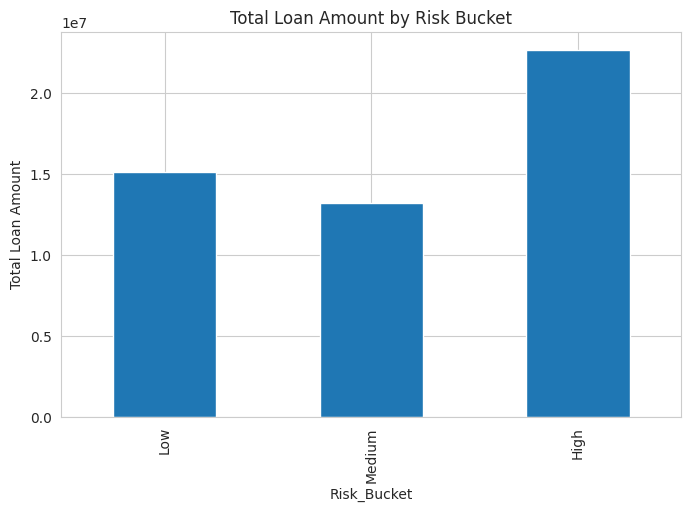

In [ ]:
# ============================================
# CELL 22: Visualize risk bucket distribution
# ============================================

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Risk_Bucket", order=["Low", "Medium", "High"])
plt.title("Count of Loans by Risk Bucket")
plt.show()

plt.figure(figsize=(8, 5))
loan_amt_by_bucket = df.groupby("Risk_Bucket")["Loan_Amount"].sum().reindex(["Low", "Medium", "High"])
loan_amt_by_bucket.plot(kind="bar")
plt.title("Total Loan Amount by Risk Bucket")
plt.ylabel("Total Loan Amount")
plt.show()

In [ ]:
# ============================================
# CELL 23: Expected Loss calculation
# Tune LGD assumption here
# ============================================

LGD = 0.45  # assumed Loss Given Default

df["Expected_Loss"] = df["PD"] * LGD * df["Loan_Amount"]

print("Total Expected Loss:", df["Expected_Loss"].sum())
print("Average Expected Loss per loan:", df["Expected_Loss"].mean())

display(df[["Loan_ID", "PD", "Loan_Amount", "Expected_Loss"]].head(10))

Total Expected Loss: 3623086.3499999996
Average Expected Loss per loan: 36230.8635


,Loan_ID,PD,Loan_Amount,Expected_Loss
0,1,0.22,399593,39559.7070
1,2,0.02,825131,7426.1790
2,3,0.18,83686,6778.5660
3,4,0.07,77661,2446.3215
4,5,0.12,578535,31240.8900
5,6,0.09,255121,10332.4005
6,7,0.11,682108,33764.3460
7,8,0.22,377257,37348.4430
8,9,0.09,276765,11208.9825
9,10,0.17,156106,11942.1090


In [ ]:
# ============================================
# CELL 24: Expected loss by segment / bucket
# ============================================

el_by_segment = df.groupby("Customer_Type")["Expected_Loss"].agg(["sum", "mean"]).reset_index()
el_by_bucket = df.groupby("Risk_Bucket")["Expected_Loss"].agg(["sum", "mean"]).reset_index()

print("Expected Loss by Customer Type")
display(el_by_segment)

print("Expected Loss by Risk Bucket")
display(el_by_bucket)

Expected Loss by Customer Type


,Customer_Type,sum,mean
0,Corporate,1347040.998,28660.446766
1,Retail,2276045.352,42944.251925


Expected Loss by Risk Bucket


,Risk_Bucket,sum,mean
0,High,2.515693e+06,61358.373220
1,Low,2.822295e+05,9407.650050
2,Medium,8.251635e+05,28453.915397


In [ ]:
# ============================================
# CELL 25: Create binary target for classification
# Tune threshold here
# ============================================

high_risk_threshold = 0.20
df["High_Risk"] = (df["PD"] >= high_risk_threshold).astype(int)

print("High Risk class distribution:")
display(df["High_Risk"].value_counts())
display(df["High_Risk"].value_counts(normalize=True))

High Risk class distribution:


,count
High_Risk,
0,59
1,41


,proportion
High_Risk,
0,0.59
1,0.41


In [ ]:
# ============================================
# CELL 26: Select features for ML
# ============================================

feature_cols = [
    "Customer_Type",
    "Annual_Income",
    "Debt_to_Income",
    "Credit_History_Length",
    "Loan_Amount",
    "Interest_Rate",
    "Loan_Term_Months",
    "Past_Default",
    "Income_to_Loan_Ratio",
    "Loan_to_Income_Ratio",
    "High_DTI_Flag",
    "Short_Credit_History_Flag"
]

X = df[feature_cols]
y_reg = df["PD"]
y_clf = df["High_Risk"]

categorical_features = ["Customer_Type"]
numeric_features = [col for col in feature_cols if col not in categorical_features]

print("Categorical features:", categorical_features)
print("Numeric features:", numeric_features)

Categorical features: ['Customer_Type']
Numeric features: ['Annual_Income', 'Debt_to_Income', 'Credit_History_Length', 'Loan_Amount', 'Interest_Rate', 'Loan_Term_Months', 'Past_Default', 'Income_to_Loan_Ratio', 'Loan_to_Income_Ratio', 'High_DTI_Flag', 'Short_Credit_History_Flag']


In [ ]:
# ============================================
# CELL 27: Preprocessing pipeline
# ============================================

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Annual_Income', 'Debt_to_Income',
                                  'Credit_History_Length', 'Loan_Amount',
                                  'Interest_Rate', 'Loan_Term_Months',
                                  'Past_Default', 'Income_to_Loan_Ratio',
                                  'Loan_to_Income_Ratio', 'High_DTI_Flag',
                                  'Short_Credit_History_Flag']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Customer_Type'])])

In [ ]:
# ============================================
# CELL 28: Train/test split for regression
# ============================================

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

print("Regression train shape:", X_train_reg.shape)
print("Regression test shape:", X_test_reg.shape)

Regression train shape: (80, 12)
Regression test shape: (20, 12)


In [ ]:
# ============================================
# CELL 29: Baseline regression model - Linear Regression
# ============================================

reg_model_lr = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

reg_model_lr.fit(X_train_reg, y_train_reg)
pred_reg_lr = reg_model_lr.predict(X_test_reg)

print("Linear Regression Performance")
print("MAE :", mean_absolute_error(y_test_reg, pred_reg_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, pred_reg_lr)))
print("R2  :", r2_score(y_test_reg, pred_reg_lr))

Linear Regression Performance
MAE : 0.07475256279595165
RMSE: 0.08134883146336638
R2  : 0.1576333527933821


In [ ]:
# ============================================
# CELL 30: Better regression model - Random Forest Regressor
# Tune parameters here
# ============================================

reg_model_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=6,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    ))
])

reg_model_rf.fit(X_train_reg, y_train_reg)
pred_reg_rf = reg_model_rf.predict(X_test_reg)

print("Random Forest Regressor Performance")
print("MAE :", mean_absolute_error(y_test_reg, pred_reg_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, pred_reg_rf)))
print("R2  :", r2_score(y_test_reg, pred_reg_rf))

Random Forest Regressor Performance
MAE : 0.07152667579959031
RMSE: 0.08098959773361315
R2  : 0.16505665210635478


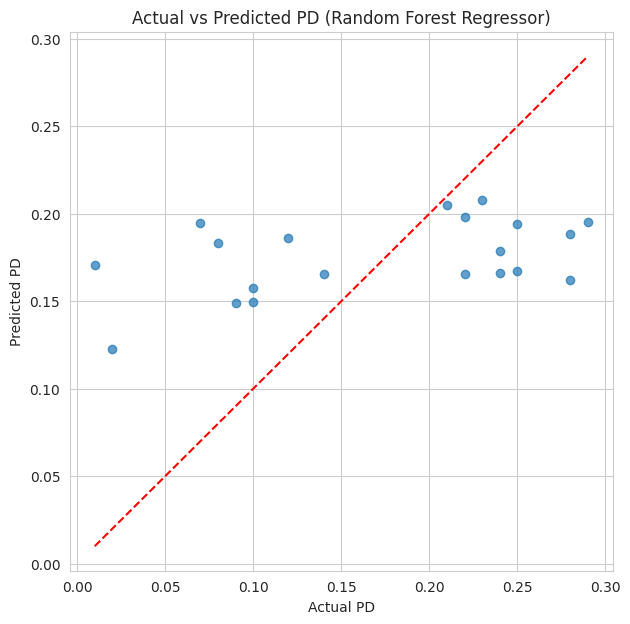

In [ ]:
# ============================================
# CELL 31: Actual vs predicted PD plot
# ============================================

plt.figure(figsize=(7, 7))
plt.scatter(y_test_reg, pred_reg_rf, alpha=0.7)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], "r--")
plt.xlabel("Actual PD")
plt.ylabel("Predicted PD")
plt.title("Actual vs Predicted PD (Random Forest Regressor)")
plt.show()

In [ ]:
# ============================================
# CELL 32: Train/test split for classification
# ============================================

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print("Classification train shape:", X_train_clf.shape)
print("Classification test shape:", X_test_clf.shape)

Classification train shape: (80, 12)
Classification test shape: (20, 12)


In [ ]:
# ============================================
# CELL 33: Baseline classifier - Logistic Regression
# ============================================

clf_model_log = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

clf_model_log.fit(X_train_clf, y_train_clf)
pred_clf_log = clf_model_log.predict(X_test_clf)
proba_clf_log = clf_model_log.predict_proba(X_test_clf)[:, 1]

print("Logistic Regression Performance")
print("Accuracy :", accuracy_score(y_test_clf, pred_clf_log))
print("Precision:", precision_score(y_test_clf, pred_clf_log, zero_division=0))
print("Recall   :", recall_score(y_test_clf, pred_clf_log, zero_division=0))
print("F1 Score :", f1_score(y_test_clf, pred_clf_log, zero_division=0))
print("ROC AUC  :", roc_auc_score(y_test_clf, proba_clf_log))

Logistic Regression Performance
Accuracy : 0.6
Precision: 0.5
Recall   : 0.375
F1 Score : 0.42857142857142855
ROC AUC  : 0.4791666666666667


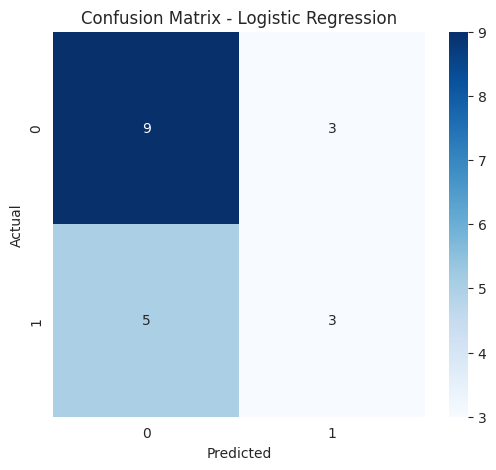

              precision    recall  f1-score   support

           0       0.64      0.75      0.69        12
           1       0.50      0.38      0.43         8

    accuracy                           0.60        20
   macro avg       0.57      0.56      0.56        20
weighted avg       0.59      0.60      0.59        20



In [ ]:
# ============================================
# CELL 34: Confusion matrix and classification report
# ============================================

cm = confusion_matrix(y_test_clf, pred_clf_log)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test_clf, pred_clf_log, zero_division=0))

In [ ]:
# ============================================
# CELL 35: Better classifier - Random Forest Classifier
# Tune parameters here
# ============================================

clf_model_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        class_weight="balanced"
    ))
])

clf_model_rf.fit(X_train_clf, y_train_clf)
pred_clf_rf = clf_model_rf.predict(X_test_clf)
proba_clf_rf = clf_model_rf.predict_proba(X_test_clf)[:, 1]

print("Random Forest Classifier Performance")
print("Accuracy :", accuracy_score(y_test_clf, pred_clf_rf))
print("Precision:", precision_score(y_test_clf, pred_clf_rf, zero_division=0))
print("Recall   :", recall_score(y_test_clf, pred_clf_rf, zero_division=0))
print("F1 Score :", f1_score(y_test_clf, pred_clf_rf, zero_division=0))
print("ROC AUC  :", roc_auc_score(y_test_clf, proba_clf_rf))

Random Forest Classifier Performance
Accuracy : 0.55
Precision: 0.42857142857142855
Recall   : 0.375
F1 Score : 0.4
ROC AUC  : 0.5


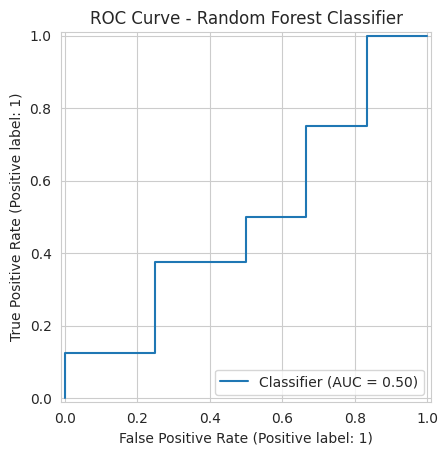

In [ ]:
# ============================================
# CELL 36: ROC curve
# ============================================

RocCurveDisplay.from_predictions(y_test_clf, proba_clf_rf)
plt.title("ROC Curve - Random Forest Classifier")
plt.show()

,Feature,Importance
8,Loan_to_Income_Ratio,0.153330
7,Income_to_Loan_Ratio,0.140268
4,Interest_Rate,0.138348
1,Debt_to_Income,0.124178
0,Annual_Income,0.111914
3,Loan_Amount,0.110770
2,Credit_History_Length,0.103360
5,Loan_Term_Months,0.043159
6,Past_Default,0.018978
12,Customer_Type_Retail,0.017662


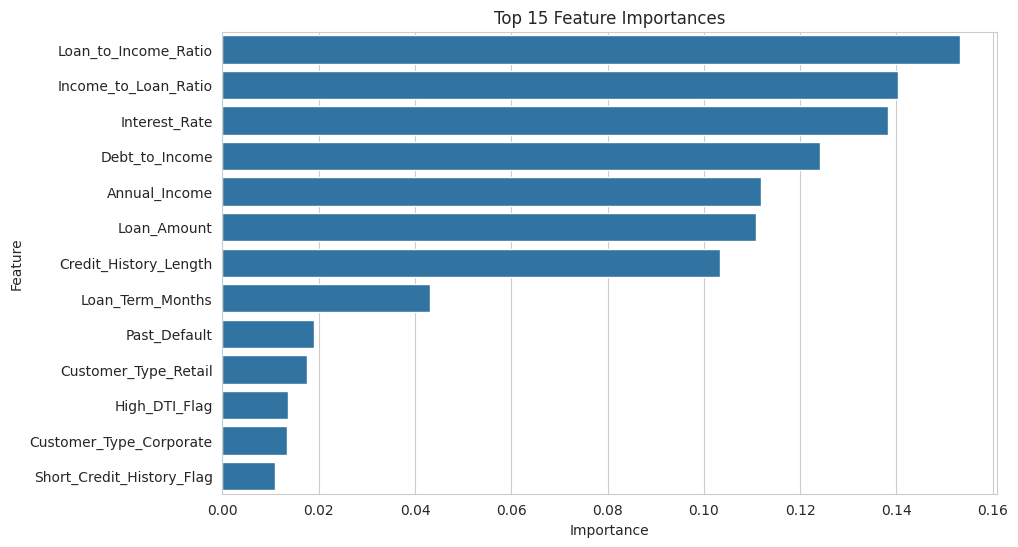

In [ ]:
# ============================================
# CELL 37: Feature importance from Random Forest Classifier
# ============================================

# Get transformed feature names
ohe = clf_model_rf.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
encoded_cat_features = list(ohe.get_feature_names_out(categorical_features))
all_feature_names = numeric_features + encoded_cat_features

importances = clf_model_rf.named_steps["model"].feature_importances_
feature_importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

display(feature_importance_df.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df.head(15), x="Importance", y="Feature")
plt.title("Top 15 Feature Importances")
plt.show()

In [ ]:
# ============================================
# CELL 38: Predict PD / risk for all rows
# ============================================

df["Predicted_PD_RF"] = reg_model_rf.predict(X)
df["Predicted_High_Risk_RF"] = clf_model_rf.predict(X)
df["Predicted_High_Risk_Prob_RF"] = clf_model_rf.predict_proba(X)[:, 1]

display(df.head())

,Loan_ID,Customer_Type,Annual_Income,Debt_to_Income,Credit_History_Length,Loan_Amount,Interest_Rate,Loan_Term_Months,Past_Default,PD,Income_to_Loan_Ratio,Loan_to_Income_Ratio,High_DTI_Flag,Short_Credit_History_Flag,Risk_Bucket,Expected_Loss,High_Risk,Predicted_PD_RF,Predicted_High_Risk_RF,Predicted_High_Risk_Prob_RF
0,1,Corporate,2676791,0.47,15,399593,13.39,36,0,0.22,6.698794,0.149281,0,0,High,39559.7070,1,0.181776,1,0.685245
1,2,Retail,2740108,0.15,23,825131,12.80,36,0,0.02,3.320816,0.301131,0,0,Low,7426.1790,0,0.129912,0,0.354647
2,3,Corporate,4863177,0.20,15,83686,6.09,48,0,0.18,58.112193,0.017208,0,0,Medium,6778.5660,0,0.121496,0,0.089612
3,4,Corporate,3383597,0.19,5,77661,5.05,48,0,0.07,43.568805,0.022952,0,0,Low,2446.3215,0,0.109979,0,0.067650
4,5,Retail,95953,0.62,21,578535,11.02,24,0,0.12,0.165855,6.029358,1,0,Medium,31240.8900,0,0.180548,0,0.284134


In [ ]:
# ============================================
# CELL 39: Simple rule-based anomaly flags
# Tune these rules for learning
# ============================================

df["Anomaly_Rule_High_DTI_Short_History"] = (
    (df["Debt_to_Income"] > 0.80) &
    (df["Credit_History_Length"] < 5)
).astype(int)

df["Anomaly_Rule_Low_Income_High_Loan"] = (
    (df["Loan_to_Income_Ratio"] > 1.5)
).astype(int)

df["Anomaly_Rule_Past_Default_High_Loan"] = (
    (df["Past_Default"] == 1) &
    (df["Loan_Amount"] > df["Loan_Amount"].quantile(0.75))
).astype(int)

df["Rule_Anomaly_Count"] = df[
    [
        "Anomaly_Rule_High_DTI_Short_History",
        "Anomaly_Rule_Low_Income_High_Loan",
        "Anomaly_Rule_Past_Default_High_Loan"
    ]
].sum(axis=1)

display(df[
    [
        "Loan_ID", "Debt_to_Income", "Credit_History_Length", "Loan_Amount",
        "Annual_Income", "Past_Default", "Rule_Anomaly_Count"
    ]
].head(10))

,Loan_ID,Debt_to_Income,Credit_History_Length,Loan_Amount,Annual_Income,Past_Default,Rule_Anomaly_Count
0,1,0.47,15,399593,2676791,0,0
1,2,0.15,23,825131,2740108,0,0
2,3,0.20,15,83686,4863177,0,0
3,4,0.19,5,77661,3383597,0,0
4,5,0.62,21,578535,95953,0,1
5,6,0.70,14,255121,4019618,0,0
6,7,0.57,2,682108,2627480,0,0
7,8,0.87,11,377257,4227571,0,0
8,9,0.40,19,276765,2952097,0,0
9,10,0.33,7,156106,187164,1,0


In [ ]:
# ============================================
# CELL 40: Isolation Forest for anomaly detection
# ============================================

anomaly_features = [
    "Annual_Income", "Debt_to_Income", "Credit_History_Length",
    "Loan_Amount", "Interest_Rate", "Loan_Term_Months",
    "Past_Default", "Income_to_Loan_Ratio", "Loan_to_Income_Ratio", "PD"
]

X_anomaly = df[anomaly_features].copy()

scaler = StandardScaler()
X_anomaly_scaled = scaler.fit_transform(X_anomaly)

iso = IsolationForest(
    n_estimators=200,
    contamination=0.10,   # tune this
    random_state=42
)

df["Anomaly_IForest"] = iso.fit_predict(X_anomaly_scaled)
df["Anomaly_IForest_Flag"] = (df["Anomaly_IForest"] == -1).astype(int)
df["Anomaly_IForest_Score"] = iso.decision_function(X_anomaly_scaled)

print("Number of anomalies flagged:", df["Anomaly_IForest_Flag"].sum())

Number of anomalies flagged: 10


In [ ]:
# ============================================
# CELL 41: View top anomalous loans
# ============================================

top_anomalies = df.sort_values(by="Anomaly_IForest_Score", ascending=True).head(15)

display(top_anomalies[
    [
        "Loan_ID", "Customer_Type", "Annual_Income", "Debt_to_Income",
        "Credit_History_Length", "Loan_Amount", "Interest_Rate",
        "Loan_Term_Months", "Past_Default", "PD",
        "Rule_Anomaly_Count", "Anomaly_IForest_Flag", "Anomaly_IForest_Score"
    ]
])

,Loan_ID,Customer_Type,Annual_Income,Debt_to_Income,Credit_History_Length,Loan_Amount,Interest_Rate,Loan_Term_Months,Past_Default,PD,Rule_Anomaly_Count,Anomaly_IForest_Flag,Anomaly_IForest_Score
58,59,Retail,2793642,0.12,4,33275,12.80,36,1,0.17,0,1,-0.061049
92,93,Retail,56790,0.72,17,800756,13.16,36,0,0.16,1,1,-0.048754
31,32,Corporate,1385531,0.86,24,11062,12.12,12,0,0.24,0,1,-0.048298
88,89,Corporate,424540,0.39,17,678406,13.52,60,1,0.01,1,1,-0.043089
50,51,Retail,4276238,0.76,23,36734,4.96,12,0,0.15,0,1,-0.031830
38,39,Corporate,2037635,0.38,2,582203,14.58,60,1,0.04,0,1,-0.022255
52,53,Corporate,3629865,0.68,11,36069,12.77,24,0,0.30,0,1,-0.018074
10,11,Retail,4759930,0.79,6,268930,5.24,24,1,0.14,0,1,-0.012360
25,26,Corporate,100640,0.46,10,580559,3.76,60,0,0.22,1,1,-0.010183
9,10,Retail,187164,0.33,7,156106,12.23,36,1,0.17,0,1,-0.006369


In [ ]:
# ============================================
# CELL 42: Final recommendation strategy
# Simple business rules for lending officers
# ============================================

def recommend_action(row):
    if row["Predicted_High_Risk_RF"] == 1 and row["Anomaly_IForest_Flag"] == 1:
        return "Reject / Immediate Review"
    elif row["Predicted_High_Risk_RF"] == 1:
        return "Approve with Strong Monitoring"
    elif row["Anomaly_IForest_Flag"] == 1:
        return "Approve with Fraud Review"
    else:
        return "Normal Approval / Monitoring"

df["Recommendation"] = df.apply(recommend_action, axis=1)

display(df[
    [
        "Loan_ID", "PD", "Predicted_PD_RF", "Predicted_High_Risk_RF",
        "Anomaly_IForest_Flag", "Recommendation"
    ]
].head(20))

,Loan_ID,PD,Predicted_PD_RF,Predicted_High_Risk_RF,Anomaly_IForest_Flag,Recommendation
0,1,0.22,0.181776,1,0,Approve with Strong Monitoring
1,2,0.02,0.129912,0,0,Normal Approval / Monitoring
2,3,0.18,0.121496,0,0,Normal Approval / Monitoring
3,4,0.07,0.109979,0,0,Normal Approval / Monitoring
4,5,0.12,0.180548,0,0,Normal Approval / Monitoring
5,6,0.09,0.123108,0,0,Normal Approval / Monitoring
6,7,0.11,0.149321,0,0,Normal Approval / Monitoring
7,8,0.22,0.171812,0,0,Normal Approval / Monitoring
8,9,0.09,0.134476,0,0,Normal Approval / Monitoring
9,10,0.17,0.163876,0,1,Approve with Fraud Review


In [ ]:
# ============================================
# CELL 43: Recommendation summary
# ============================================

recommendation_summary = df.groupby("Recommendation").agg(
    Loan_Count=("Loan_ID", "count"),
    Total_Loan_Amount=("Loan_Amount", "sum"),
    Avg_PD=("PD", "mean"),
    Avg_Predicted_PD=("Predicted_PD_RF", "mean")
).reset_index()

display(recommendation_summary)

,Recommendation,Loan_Count,Total_Loan_Amount,Avg_PD,Avg_Predicted_PD
0,Approve with Fraud Review,8,3136969,0.132500,0.142856
1,Approve with Strong Monitoring,37,21868721,0.233243,0.186216
2,Normal Approval / Monitoring,53,25923907,0.103585,0.137671
3,Reject / Immediate Review,2,47131,0.270000,0.183486


In [ ]:
# ============================================
# CELL 44: Export final enriched dataset
# ============================================

output_file = "/content/loan_portfolio_enriched_output.csv"
df.to_csv(output_file, index=False)
print("Saved:", output_file)

Saved: /content/loan_portfolio_enriched_output.csv


In [ ]:
# ============================================
# CELL 45: Optional - display final columns
# ============================================

print(df.columns.tolist())
display(df.head())

['Loan_ID', 'Customer_Type', 'Annual_Income', 'Debt_to_Income', 'Credit_History_Length', 'Loan_Amount', 'Interest_Rate', 'Loan_Term_Months', 'Past_Default', 'PD', 'Income_to_Loan_Ratio', 'Loan_to_Income_Ratio', 'High_DTI_Flag', 'Short_Credit_History_Flag', 'Risk_Bucket', 'Expected_Loss', 'High_Risk', 'Predicted_PD_RF', 'Predicted_High_Risk_RF', 'Predicted_High_Risk_Prob_RF', 'Anomaly_Rule_High_DTI_Short_History', 'Anomaly_Rule_Low_Income_High_Loan', 'Anomaly_Rule_Past_Default_High_Loan', 'Rule_Anomaly_Count', 'Anomaly_IForest', 'Anomaly_IForest_Flag', 'Anomaly_IForest_Score', 'Recommendation']


,Loan_ID,Customer_Type,Annual_Income,Debt_to_Income,Credit_History_Length,Loan_Amount,Interest_Rate,Loan_Term_Months,Past_Default,PD,...,Predicted_High_Risk_RF,Predicted_High_Risk_Prob_RF,Anomaly_Rule_High_DTI_Short_History,Anomaly_Rule_Low_Income_High_Loan,Anomaly_Rule_Past_Default_High_Loan,Rule_Anomaly_Count,Anomaly_IForest,Anomaly_IForest_Flag,Anomaly_IForest_Score,Recommendation
0,1,Corporate,2676791,0.47,15,399593,13.39,36,0,0.22,...,1,0.685245,0,0,0,0,1,0,0.118650,Approve with Strong Monitoring
1,2,Retail,2740108,0.15,23,825131,12.80,36,0,0.02,...,0,0.354647,0,0,0,0,1,0,0.067505,Normal Approval / Monitoring
2,3,Corporate,4863177,0.20,15,83686,6.09,48,0,0.18,...,0,0.089612,0,0,0,0,1,0,0.016767,Normal Approval / Monitoring
3,4,Corporate,3383597,0.19,5,77661,5.05,48,0,0.07,...,0,0.067650,0,0,0,0,1,0,0.039804,Normal Approval / Monitoring
4,5,Retail,95953,0.62,21,578535,11.02,24,0,0.12,...,0,0.284134,0,1,0,1,1,0,0.012880,Normal Approval / Monitoring


In [ ]:
How to learn from this notebook
You should change one thing at a time and observe the impact, for example: changing the risk thresholds in the risk bucket cell changes how many loans fall into low/medium/high groups, and changing the high-risk PD cutoff changes the classification target itself. You can also tune model hyperparameters such as n_estimators, max_depth, and contamination to see how model performance and anomaly counts change for the same portfolio.

Best places to experiment
Change low_threshold and high_threshold in the risk bucket cell.

Change LGD in the expected loss cell.

Change high_risk_threshold in the classification label cell.

Add/remove derived features like Loan_to_Income_Ratio.

Tune RandomForestRegressor and RandomForestClassifier parameters.

Change contamination in Isolation Forest from 0.05 to 0.15.

Add new anomaly rules based on your business understanding.